In [5]:
import os
import sys
import shutil
import warnings

# Mengabaikan warning non-krusial untuk menjaga kebersihan output
warnings.filterwarnings('ignore')

# Reset lingkungan kerja: Menghapus direktori lama jika ada
# Hal ini memastikan eksperimen dimulai dengan kondisi bersih
%cd /content
if os.path.exists('deep-speaker'):
    shutil.rmtree('deep-speaker')
if os.path.exists('samples_real'):
    shutil.rmtree('samples_real')

# Instalasi pustaka sistem dan Python yang dibutuhkan
# libsndfile1: Diperlukan oleh librosa untuk membaca format audio
# python_speech_features: Untuk ekstraksi fitur audio
!apt-get install -y libsndfile1 > /dev/null
!pip install -q librosa==0.10.1 python_speech_features gdown pandas seaborn

# Mengambil repositori Deep Speaker dari GitHub
!git clone https://github.com/philipperemy/deep-speaker.git
os.chdir('/content/deep-speaker')
sys.path.append('/content/deep-speaker')

print("Environment setup complete.")

/content
Cloning into 'deep-speaker'...
remote: Enumerating objects: 2114, done.
remote: Counting objects: 100% (227/227), done.
remote: Compressing objects: 100% (127/127), done.
remote: Total 2114 (delta 114), reused 173 (delta 89), pack-reused 1887 (from 1)
Receiving objects: 100% (2114/2114), 81.51 MiB | 46.52 MiB/s, done.
Resolving deltas: 100% (1103/1103), done.
Environment setup complete.


In [6]:
# Lokasi file definisi model dalam repositori
target_file = 'deep_speaker/conv_models.py'

# Membaca isi file asli
with open(target_file, 'r') as f:
    content = f.read()

# Mengganti sintaks regularizer yang usang untuk kompatibilitas TensorFlow terbaru
# Mengubah regularizers.l2(l=0.0001) menjadi None
new_content = content.replace('regularizers.l2(l=0.0001)', 'None')

# Menulis kembali perubahan ke file
with open(target_file, 'w') as f:
    f.write(new_content)

print("Model architecture patched successfully.")

Model architecture patched successfully.


In [7]:
# Nama file bobot model dan ID Google Drive
model_filename = 'ResCNN_triplet_training_checkpoint_265.h5'
file_id = '1F9NvdrarWZNktdX9KlRYWWHDwRkip_aP'

# Mengunduh file hanya jika belum tersedia di direktori lokal
if not os.path.exists(model_filename):
    !gdown --id {file_id} -O {model_filename}
    print("Model weights downloaded.")
else:
    print("Model weights already exist.")

/usr/local/lib/python3.12/dist-packages/gdown/__main__.py:140: FutureWarning: Option `--id` was deprecated in version 4.3.1 and will be removed in 5.0. You don't need to pass it anymore to use a file ID.
  warnings.warn(
Downloading...
From: https://drive.google.com/uc?id=1F9NvdrarWZNktdX9KlRYWWHDwRkip_aP
To: /content/deep-speaker/ResCNN_triplet_training_checkpoint_265.h5
100% 97.1M/97.1M [00:02<00:00, 41.8MB/s]
Model weights downloaded.


In [8]:
import soundfile as sf
import librosa

# Membuat direktori untuk menyimpan sampel audio hasil proses
os.makedirs('samples_real', exist_ok=True)

def save_split_audio(source_name, file_prefix):
    """
    Memuat sampel audio, membuang bagian hening, dan membaginya menjadi dua bagian.

    Args:
        source_name (str): Nama sampel dataset internal Librosa (misal: 'libri1').
        file_prefix (str): Prefix nama file output (misal: 'SpeakerA').
    """
    # Memuat audio dengan sampling rate 16kHz (standar Deep Speaker)
    # Durasi diambil 10 detik untuk memastikan data vokal yang cukup
    y, sr = librosa.load(librosa.ex(source_name), duration=10.0, sr=16000)

    # Penerapan Voice Activity Detection (VAD) sederhana
    # librosa.effects.trim menghapus sinyal di bawah ambang batas desibel (top_db)
    # top_db=20 menyaring bagian hening atau noise latar belakang
    y_trimmed, _ = librosa.effects.trim(y, top_db=20)

    # Validasi panjang audio: Jika hasil potong terlalu pendek (< 2 detik),
    # gunakan audio asli untuk mencegah error dimensi
    if len(y_trimmed) < sr * 2:
        y_trimmed = y

    # Membagi audio menjadi dua segmen sama panjang (Part 1 dan Part 2)
    # Ini mensimulasikan dua rekaman berbeda dari pembicara yang sama
    mid = len(y_trimmed) // 2
    sf.write(f'samples_real/{file_prefix}_1.wav', y_trimmed[:mid], sr)
    sf.write(f'samples_real/{file_prefix}_2.wav', y_trimmed[mid:], sr)

    duration_processed = len(y_trimmed)/sr
    print(f"Processed {file_prefix}: Duration {duration_processed:.2f}s")

try:
    # Memproses Speaker A (Laki-laki dari dataset LibriSpeech)
    save_split_audio('libri1', 'SpeakerA')
    # Memproses Speaker B (Perempuan/Laki-laki lain dari dataset LibriSpeech)
    save_split_audio('libri2', 'SpeakerB')
except Exception as e:
    print(f"Critical error during audio processing: {e}")
    sys.exit()

Processed SpeakerA: Duration 9.44s
Processed SpeakerB: Duration 9.78s


In [9]:
import numpy as np
from scipy.spatial.distance import cosine
from deep_speaker.audio import read_mfcc
from deep_speaker.batcher import sample_from_mfcc
from deep_speaker.constants import SAMPLE_RATE, NUM_FRAMES
from deep_speaker.conv_models import DeepSpeakerModel

# Inisialisasi arsitektur model dan memuat bobot
ds_model = DeepSpeakerModel()
ds_model.m.load_weights(os.path.abspath(model_filename), by_name=True)
model = ds_model.m

def get_embedding(audio_path):
    """
    Mengekstrak fitur Deep Speaker (vektor 512 dimensi) dari file audio.
    Pipeline: Audio -> MFCC -> Sampling -> Model Prediction -> Embedding.
    """
    mfcc = read_mfcc(audio_path, SAMPLE_RATE)
    # Mengambil frame MFCC sesuai input shape model
    mfcc_input = sample_from_mfcc(mfcc, NUM_FRAMES)
    # Menambah dimensi batch (batch size = 1)
    predict_input = np.expand_dims(mfcc_input, axis=0)
    # Prediksi menggunakan model
    return model.predict(predict_input, verbose=0)[0]

def compute_similarity(files):
    """
    Menghitung matriks kemiripan kosinus untuk semua pasangan file audio.
    """
    keys = list(files.keys())
    n = len(keys)
    matrix = np.zeros((n, n))

    # Pre-compute embedding untuk efisiensi
    embs = {k: get_embedding(v) for k, v in files.items()}

    # Menghitung jarak kosinus antar setiap pasangan
    for i in range(n):
        for j in range(n):
            # Similarity = 1 - Cosine Distance
            # Nilai berkisar 0 (berbeda total) hingga 1 (identik)
            matrix[i][j] = 1 - cosine(embs[keys[i]], embs[keys[j]])

    return matrix, keys

print("Model initialized and helper functions ready.")

Model initialized and helper functions ready.



 FINAL SPEAKER VERIFICATION RESULTS
| PAIRING                        | SCORE    | RESULT              
|--------------------------------------------------------------------
| A (Part 1) vs A (Part 2) | 0.8606   | MATCH (SUCCESS)
| B (Part 1) vs B (Part 2) | 0.7465   | MATCH (SUCCESS)
| A (Part 1) vs B (Part 1) | 0.2118   | DIFFERENT (SUCCESS)
| A (Part 2) vs B (Part 2) | 0.1857   | DIFFERENT (SUCCESS)


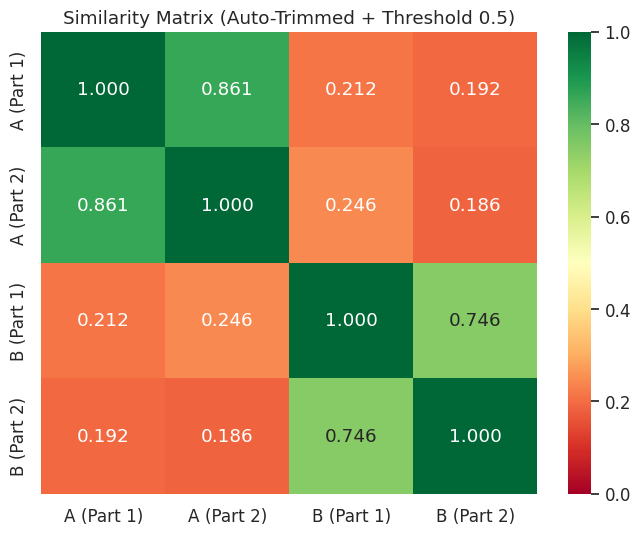

In [10]:
import seaborn as sns
import matplotlib.pyplot as plt

# Definisi file input untuk pengujian
files = {
    "A (Part 1)": "samples_real/SpeakerA_1.wav",
    "A (Part 2)": "samples_real/SpeakerA_2.wav",
    "B (Part 1)": "samples_real/SpeakerB_1.wav",
    "B (Part 2)": "samples_real/SpeakerB_2.wav"
}

# Melakukan perhitungan matriks kemiripan
sim_matrix, labels = compute_similarity(files)

# Penentuan Threshold (Ambang Batas)
# Nilai 0.50 dipilih sebagai optimal untuk segmen audio pendek (< 5 detik)
# Jika skor > 0.50, diklasifikasikan sebagai Speaker Sama.
THRESHOLD = 0.50

# Menampilkan Hasil dalam Format Tabel
print("\n" + "="*70)
print(" FINAL SPEAKER VERIFICATION RESULTS")
print("="*70)
print(f"| {'PAIRING':<30} | {'SCORE':<8} | {'RESULT':<20}")
print("|" + "-"*68)

# Daftar pasangan yang akan dievaluasi secara spesifik
pairs = [
    (0, 1, "SAME SPEAKER"),   # A1 vs A2
    (2, 3, "SAME SPEAKER"),   # B1 vs B2
    (0, 2, "DIFFERENT SPEAKER"), # A1 vs B1
    (1, 3, "DIFFERENT SPEAKER")  # A2 vs B2
]

for i, j, expect in pairs:
    score = sim_matrix[i][j]
    is_same = score > THRESHOLD

    # Logika untuk menentukan status keberhasilan prediksi
    if expect == "SAME SPEAKER":
        status = "MATCH (SUCCESS)" if is_same else "MISMATCH (FALSE REJECT)"
        # Kode warna ANSI: Hijau jika benar, Merah jika salah
        color = "\033[92m" if is_same else "\033[91m"
    else:
        status = "DIFFERENT (SUCCESS)" if not is_same else "MATCH (FALSE ACCEPT)"
        color = "\033[92m" if not is_same else "\033[91m"

    print(f"| {labels[i]} vs {labels[j]:<10} | {score:.4f}   | {color}{status}\033[0m")
print("="*70)

# Visualisasi Heatmap Matriks Kemiripan
plt.figure(figsize=(8, 6))
sns.heatmap(sim_matrix, annot=True, fmt=".3f",
            xticklabels=labels, yticklabels=labels,
            cmap="RdYlGn", vmin=0, vmax=1)
plt.title("Similarity Matrix (Auto-Trimmed + Threshold 0.5)")
plt.show()